In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import numpy as np
pd.set_option('display.max_columns', None)

Data temizlenmesi


In [37]:
df = pd.read_csv('diabetic_data.csv')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [39]:
df.shape

(101766, 50)

In [40]:
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

In [41]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [42]:
df["gender"].unique()

<StringArray>
['Female', 'Male', 'Unknown/Invalid']
Length: 3, dtype: str

In [43]:
df["gender"].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [44]:
df[df["gender"]=="Unknown/Invalid"]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
30506,98634858,100695042,Other,Unknown/Invalid,[70-80),?,3,1,1,1,?,Cardiology,5,5,22,0,0,0,414,411,401,4,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
75551,226864668,60524946,?,Unknown/Invalid,[60-70),?,1,1,7,1,CP,?,38,1,6,0,0,0,808,873,E813,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
82573,257364294,78119847,?,Unknown/Invalid,[70-80),?,1,22,7,8,CP,?,59,2,21,0,0,0,850,805,808,9,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO


In [45]:
df.replace('Unknown/Invalid',np.nan, inplace=True)
df.dropna(subset=["gender"],inplace=True)

In [46]:
df.isnull().sum()/df.shape[0]*100

encounter_id                 0.000000
patient_nbr                  0.000000
race                         0.000000
gender                       0.000000
age                          0.000000
weight                       0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                   0.000000
medical_specialty            0.000000
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.000000
diag_2                       0.000000
diag_3                       0.000000
number_diagnoses             0.000000
max_glu_serum               94.746617
A1Cresult                   83.276829
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [47]:
df.drop(["weight", "encounter_id", "patient_nbr", "max_glu_serum", "A1Cresult"], axis=1, inplace=True)


In [48]:
df[df["medical_specialty"].isnull()]

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


In [49]:
def icd_group(code):
    if pd.isnull(code):
        return 'Unknown'

    code = str(code)

    if code.startswith('V') or code.startswith('E'):
        return 'External'

    try:
        code_num = float(code)
    except:
        return 'Other'

    if 250 <= code_num < 251:
        return 'Diabetes'
    elif 390 <= code_num < 460:
        return 'Circulatory'
    elif 460 <= code_num < 520:
        return 'Respiratory'
    elif 520 <= code_num < 580:
        return 'Digestive'
    elif 800 <= code_num < 1000:
        return 'Injury'
    else:
        return 'Other'

In [50]:
df['diag_1_group'] = df['diag_1'].apply(icd_group)
df['diag_2_group'] = df['diag_2'].apply(icd_group)
df['diag_3_group'] = df['diag_3'].apply(icd_group)

In [51]:
df.drop(["diag_1", "diag_2", "diag_3"], axis=1, inplace=True)

In [52]:
df["metformin"].value_counts()

metformin
No        81776
Steady    18345
Up         1067
Down        575
Name: count, dtype: int64

In [53]:
df['readmitted'].value_counts()

readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64

In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101763 non-null  str  
 1   gender                    101763 non-null  str  
 2   age                       101763 non-null  str  
 3   admission_type_id         101763 non-null  int64
 4   discharge_disposition_id  101763 non-null  int64
 5   admission_source_id       101763 non-null  int64
 6   time_in_hospital          101763 non-null  int64
 7   payer_code                101763 non-null  str  
 8   medical_specialty         101763 non-null  str  
 9   num_lab_procedures        101763 non-null  int64
 10  num_procedures            101763 non-null  int64
 11  num_medications           101763 non-null  int64
 12  number_outpatient         101763 non-null  int64
 13  number_emergency          101763 non-null  int64
 14  number_inpatient          101763 non

Encoding


In [55]:
drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone',"diabetesMed"
]

categorical_cols = [
    'race','gender','age','weight','payer_code','medical_specialty',
    'max_glu_serum','A1Cresult','change','diabetesMed',
    'admission_type_id','discharge_disposition_id','admission_source_id'
] + drug_cols

In [56]:
age_order = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2,
    '[30-40)': 3, '[40-50)': 4, '[50-60)': 5,
    '[60-70)': 6, '[70-80)': 7, '[80-90)': 8,
    '[90-100)': 9
}

df['age_encoded'] = df['age'].map(age_order)
df.drop("age",axis=1,inplace=True)

In [57]:
df['readmitted'] = df['readmitted'].map({
    '<30': 1,
    '>30': 0,
    'NO': 0
})

In [58]:
drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone',"diabetesMed"
]
def map_drug(val):
    if val == 'No':
        return 0
    elif val in ['Steady', 'Yes']:
        return 1
    elif val == 'Up':
        return 2
    elif val == 'Down':
        return 3
    else:
        return np.nan  # sonra ayrıca handle et

for col in drug_cols:
    df[col] = df[col].apply(map_drug)

In [59]:
df = pd.get_dummies(df, columns=[
    'race', 'gender', 'payer_code',
    'medical_specialty',
    'diag_1_group', 'diag_2_group', 'diag_3_group'
], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [60]:
df['change'] = df['change'].map({
    'No': 0,
    'Ch': 1
})

In [61]:
X = df.drop('readmitted', axis=1).copy()
y = df['readmitted'].copy()

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(    X, y,    test_size=0.3,    random_state=42,    stratify=y   
)

In [63]:
from sklearn.preprocessing import LabelEncoder

# X-in string sütunlarını encode et
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))


X.dtypes

admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
                            ...  
diag_3_group_Digestive      int64
diag_3_group_External       int64
diag_3_group_Injury         int64
diag_3_group_Other          int64
diag_3_group_Respiratory    int64
Length: 150, dtype: object

In [64]:
y.value_counts()

readmitted
0    90406
1    11357
Name: count, dtype: int64

In [65]:

xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    scale_pos_weight=1,
    reg_lambda=2,
    reg_alpha=1,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [66]:
param_dist = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
    "model__gamma": [0, 0.1],
    "model__scale_pos_weight": [
        len(y_train[y_train==0]) / len(y_train[y_train==1])
    ]
}

In [67]:
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import optuna

def objective(trial):

    smote = SMOTETomek(random_state=42)

    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 300, 1000),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1),
        max_depth=trial.suggest_int('max_depth', 3, 7),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 7),
        subsample=trial.suggest_float('subsample', 0.6, 0.9),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 0.9),
        gamma=trial.suggest_float('gamma', 0, 5),
        reg_alpha=trial.suggest_float('reg_alpha', 0, 2),
        reg_lambda=trial.suggest_float('reg_lambda', 1, 5),
        eval_metric='auc'
    )

    pipe = Pipeline([
        ('smote', smote),
        ('model', model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=3
    ).mean()

    return score

In [71]:
y_test_pred = xgb_model.predict(X_test)

print(accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

0.8889907956369354
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     27122
           1       0.60      0.02      0.03      3407

    accuracy                           0.89     30529
   macro avg       0.75      0.51      0.49     30529
weighted avg       0.86      0.89      0.84     30529

[[27088    34]
 [ 3355    52]]


In [73]:
probs = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.2

y_pred_thresh = (probs > threshold).astype(int)

print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91     27122
           1       0.28      0.24      0.26      3407

    accuracy                           0.85     30529
   macro avg       0.59      0.58      0.58     30529
weighted avg       0.84      0.85      0.84     30529



In [75]:
from sklearn.metrics import roc_auc_score

y_true = y_test
y_score = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_true, y_score)

print("ROC-AUC:", auc)

ROC-AUC: 0.6817420635545045


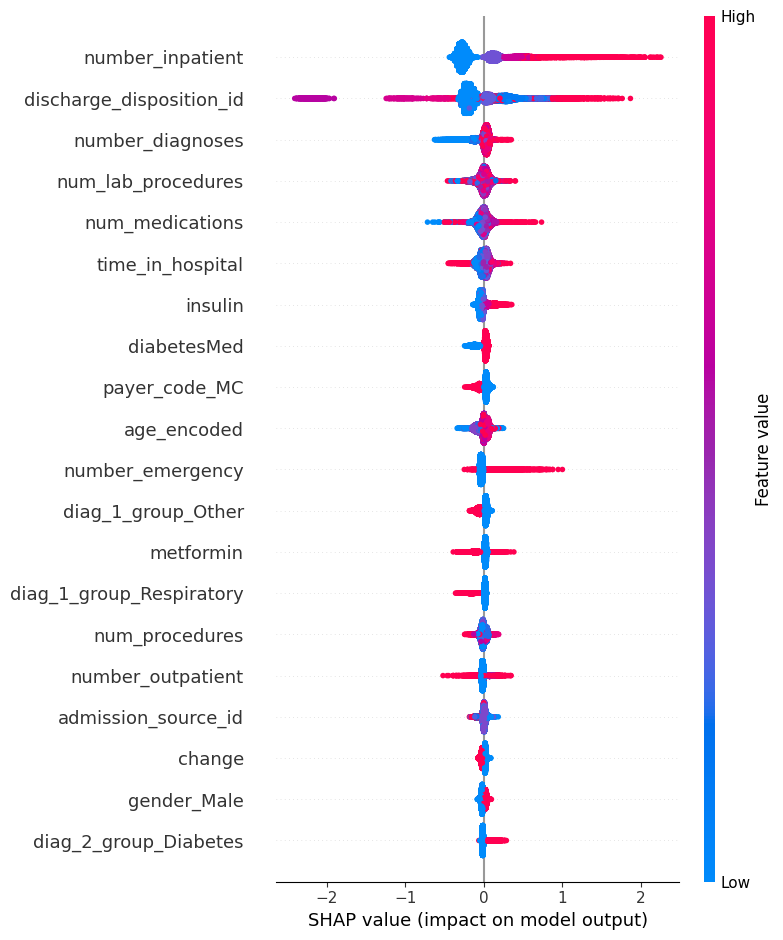

In [76]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

Bu SHAP qrafiki modelin qərarlarının arxasında hansı faktorların dayandığını ümumi şəkildə göstərir. Xüsusiyyətlər (feature-lər) yuxarıdan aşağıya doğru təsir gücünə görə sıralanıb və bu da modelin hansı məlumatlara daha çox “önəm verdiyini” aydın göstərir.

Qrafikə baxdıqda ən dominant dəyişənin number_inpatient olduğu görünür. Bu dəyişənin yüksək qiymətləri əsasən proqnozu artıran istiqamətdə təsir göstərir. Yəni, xəstənin əvvəlki hospitalizasiya sayı çox olduqda model onu daha yüksək risk kateqoriyasına yaxınlaşdırır.

Sonrakı sıralarda diag_1 və number_outpatient gəlir. Bu dəyişənlər də model üçün əhəmiyyətlidir, lakin onların təsiri daha çox yayılmış şəkildədir — həm müsbət, həm də mənfi istiqamətdə dəyişə bilir. Bu isə onların kontekstdən asılı olaraq fərqli rol oynadığını göstərir.

number_emergency dəyişəni də diqqət çəkir. Qrafikdə görünür ki, bu dəyişənin yüksək dəyərləri əsasən nəticəni artırır. Bu, tez-tez təcili müraciət edən xəstələrin daha riskli hesab olunduğunu göstərir.

Orta səviyyəli təsirə malik dəyişənlər arasında medical_specialty, payer_code, diabetesMed və number_diagnoses var. Bu faktorlar model qərarına təsir etsə də, təsirləri daha zəif və balanslıdır — yəni qərarı kəskin şəkildə dəyişmirlər.

Daha aşağı hissədə yerləşən dəyişənlər, məsələn age, num_medications, time_in_hospital, insulin, metformin və digərləri model üçün ikinci dərəcəli rol oynayır. Bu dəyişənlərin SHAP dəyərləri sıfıra yaxın olduğuna görə onların təsiri məhduddur.

Qrafikdə rənglər də vacib informasiya verir:

Qırmızı nöqtələr yüksək dəyərləri göstərir
Mavi nöqtələr isə aşağı dəyərləri
Nöqtələrin sağ tərəfə getməsi model çıxışını artırır, sol tərəfə getməsi isə azaldır

Ümumi nəticə olaraq demək olar ki, model əsas qərarlarını daha çox xəstənin əvvəlki tibbi tarixçəsinə (xüsusilə hospitalizasiya və müraciət sayı) əsaslanaraq verir. Digər dəyişənlər isə bu qərarı dəstəkləyən əlavə faktorlar kimi çıxış edir.

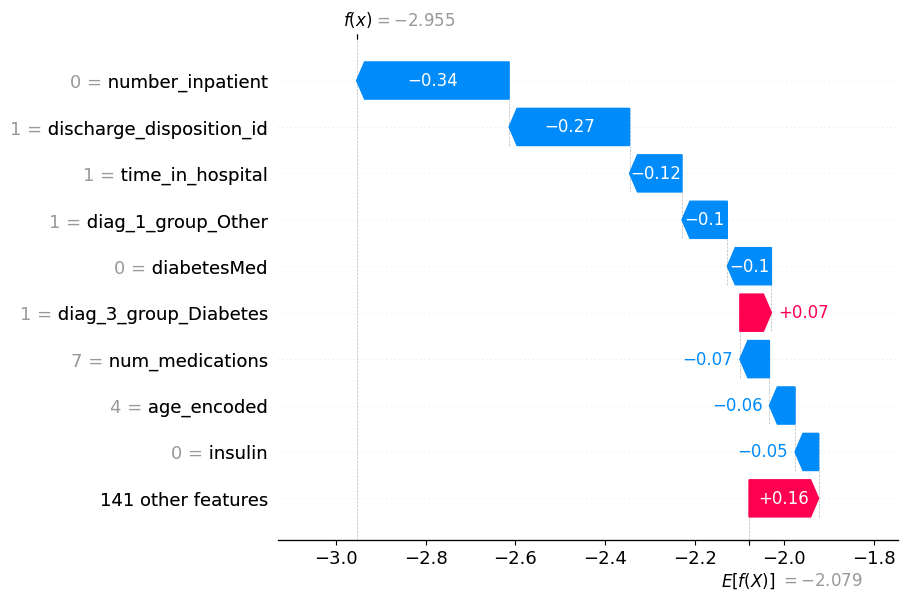

In [77]:
shap.plots.waterfall(shap_values[0])

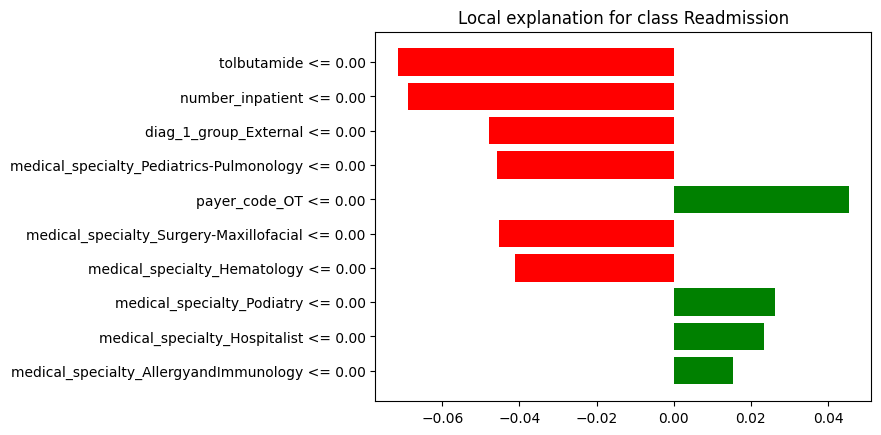

In [86]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['No Readmission', 'Readmission'],
    mode='classification'
)

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    xgb_model.predict_proba
)

import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
plt.show()

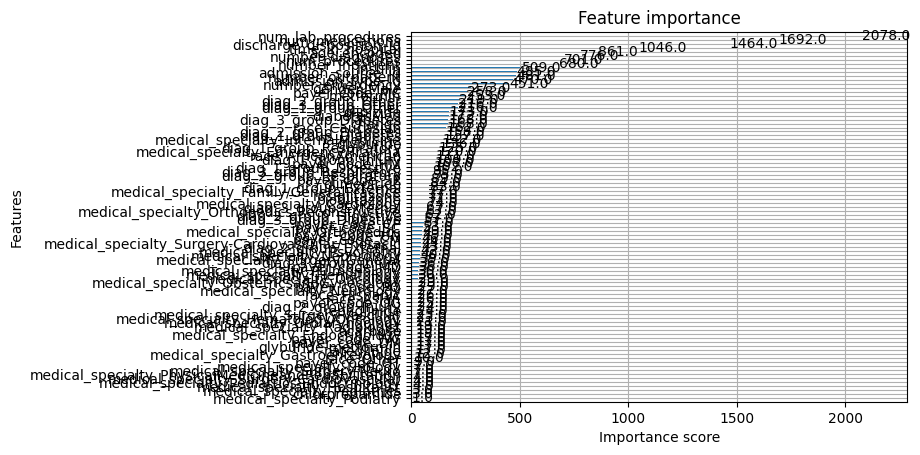

In [85]:
import matplotlib.pyplot as plt
import xgboost as xgb
xgb.plot_importance(xgb_model)
plt.show()